In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Convert to list of lists
data_list = iris.data.tolist()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map(dict(enumerate(iris.target_names)))

print("First 5 rows of dataset:")
print(df.head())

First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [2]:
print("\nMean of each measurement column:")
print(df.iloc[:,0:4].mean())

print("\nStandard Deviation of each measurement column:")
print(df.iloc[:,0:4].std())


Mean of each measurement column:
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

Standard Deviation of each measurement column:
sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64


In [3]:
print("\nMean by species:")
print(df.groupby('species').mean())

print("\nStandard deviation by species:")
print(df.groupby('species').std())


Mean by species:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                  5.006             3.428              1.462   
versicolor              5.936             2.770              4.260   
virginica               6.588             2.974              5.552   

            petal width (cm)  
species                       
setosa                 0.246  
versicolor             1.326  
virginica              2.026  

Standard deviation by species:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa               0.352490          0.379064           0.173664   
versicolor           0.516171          0.313798           0.469911   
virginica            0.635880          0.322497           0.551895   

            petal width (cm)  
species                       
setosa              0.105386  


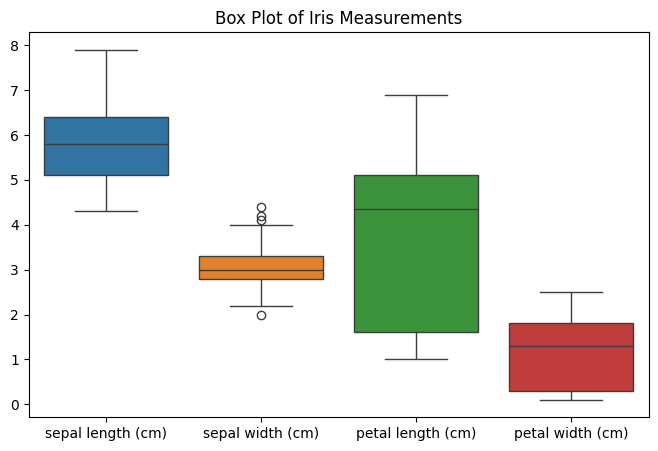

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df.iloc[:,0:4])
plt.title("Box Plot of Iris Measurements")
plt.show()

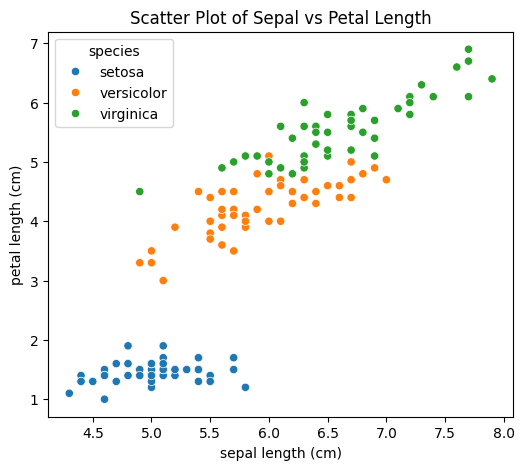

In [5]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='sepal length (cm)', y='petal length (cm)', hue='species', data=df)
plt.title("Scatter Plot of Sepal vs Petal Length")
plt.show()

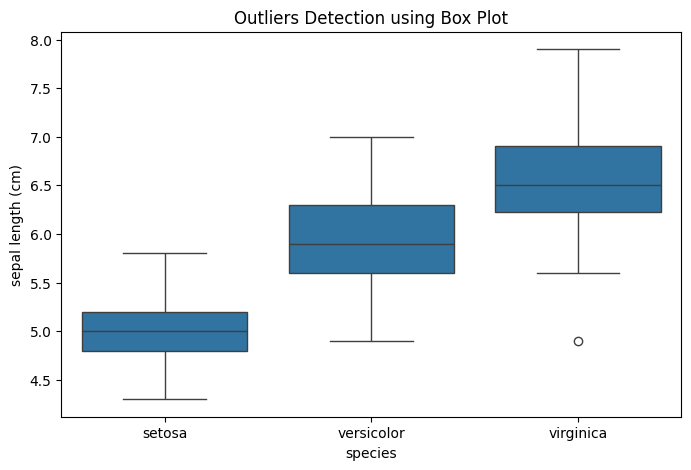

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x='species', y='sepal length (cm)', data=df)
plt.title("Outliers Detection using Box Plot")
plt.show()

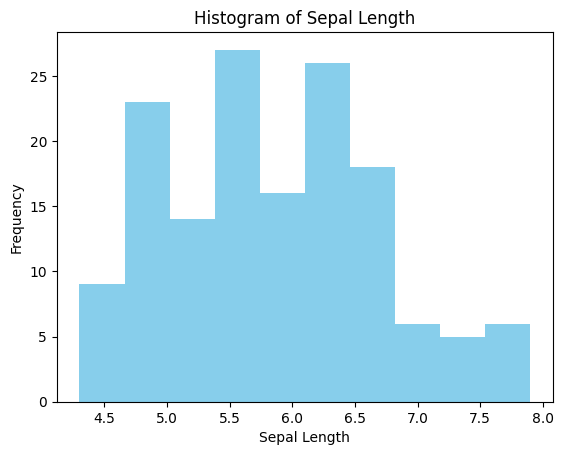

In [7]:
plt.hist(df['sepal length (cm)'], bins=10, color='skyblue')
plt.title("Histogram of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()

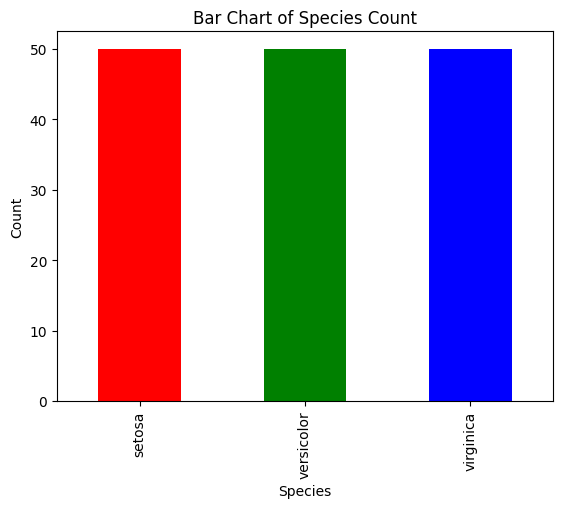

In [8]:
species_count = df['species'].value_counts()

species_count.plot(kind='bar', color=['red','green','blue'])
plt.title("Bar Chart of Species Count")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

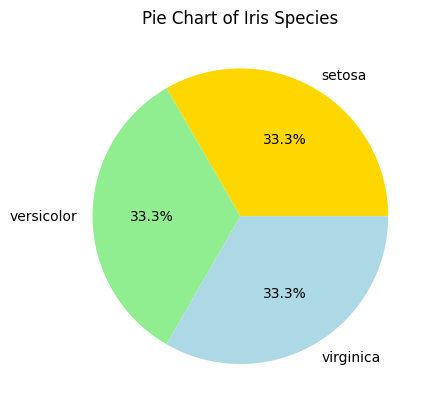

In [9]:
plt.pie(species_count, labels=species_count.index, autopct='%1.1f%%', colors=['gold','lightgreen','lightblue'])
plt.title("Pie Chart of Iris Species")
plt.show()

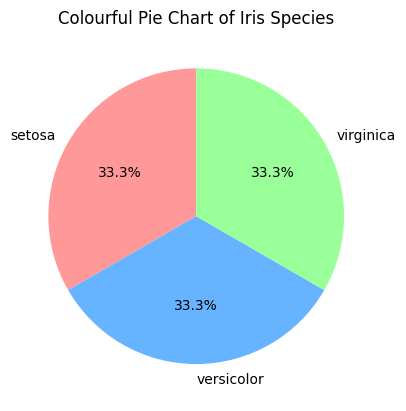

In [10]:
colors = ['#ff9999','#66b3ff','#99ff99']

plt.pie(species_count, labels=species_count.index,
        autopct='%1.1f%%', startangle=90,
        colors=colors)

plt.title("Colourful Pie Chart of Iris Species")
plt.show()

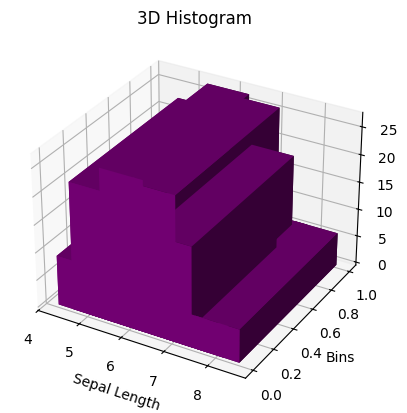

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

hist, xedges = np.histogram(df['sepal length (cm)'], bins=10)

xpos = xedges[:-1]
ypos = np.zeros_like(xpos)

zpos = np.zeros_like(xpos)

dx = np.ones_like(xpos)
dy = np.ones_like(xpos)
dz = hist

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color='purple')

ax.set_title("3D Histogram")
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Bins")
ax.set_zlabel("Frequency")

plt.show()

In [12]:
from sklearn.linear_model import LinearRegression

X = df[['petal length (cm)']]
y = df['petal width (cm)']

model = LinearRegression()
model.fit(X,y)

print("Regression Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Regression Coefficient: [0.41575542]
Intercept: -0.3630755213190291


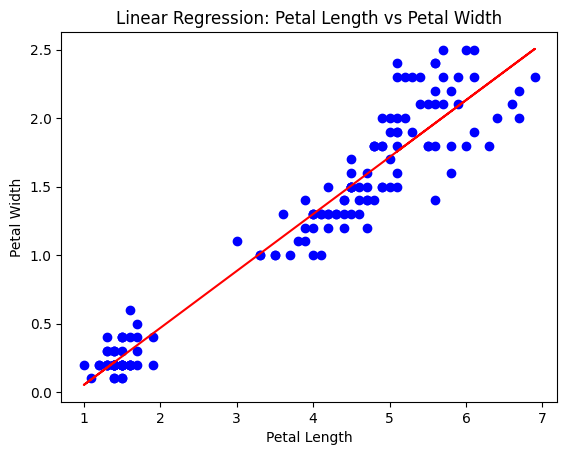

In [13]:
plt.scatter(X,y,color='blue')
plt.plot(X, model.predict(X), color='red')
plt.title("Linear Regression: Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

In [14]:
corr = df.iloc[:,0:4].corr()

print("Correlation Matrix:")
print(corr)

Correlation Matrix:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


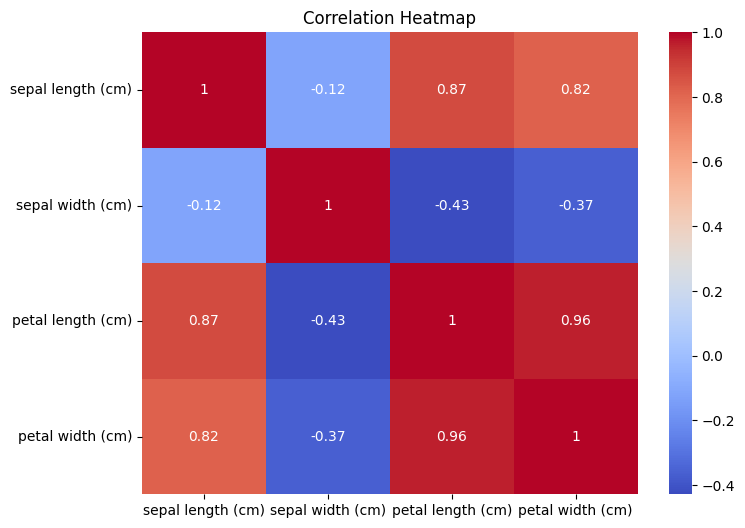

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [16]:
from scipy.stats import f_oneway

setosa = df[df['species']=='setosa']['sepal length (cm)']
versicolor = df[df['species']=='versicolor']['sepal length (cm)']
virginica = df[df['species']=='virginica']['sepal length (cm)']

f_stat, p_value = f_oneway(setosa, versicolor, virginica)

print("F-Statistic:", f_stat)
print("P-value:", p_value)

F-Statistic: 119.26450218450468
P-value: 1.6696691907693826e-31
